In [3]:
# 📘 Performance Analytics - Task 1
# Compute Daily Returns
# Objective

# Compute

# Daily Return =  Daily Return=(NAVt−1/NAVt)−1

# for all 40 schemes.

# Then verify the distribution.

# Step 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2 — Load Datasets
nav = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\02_nav_history.csv"
)

fund = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\01_fund_master.csv"
)

# Step 3 — Convert Date
nav["date"] = pd.to_datetime(nav["date"])

# Step 4 — Sort Data
nav = nav.sort_values(
    ["amfi_code","date"]
)

# Step 5 — Compute Daily Returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
) 

# Step 6 — Remove First NaN

# Each fund's first record has no previous NAV.

returns = nav.dropna(
    subset=["daily_return"]
)


# Step 7 — Merge Scheme Names
returns = returns.merge(
    fund[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
) 

In [4]:
print(returns.shape)

print(returns["daily_return"].isnull().sum())

print(returns["daily_return"].describe())

returns.head() 

(45960, 5)
0
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


,amfi_code,date,nav,daily_return,scheme_name
0,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-10,510.7136,-0.008639,HDFC Top 100 Fund - Regular Plan - Growth


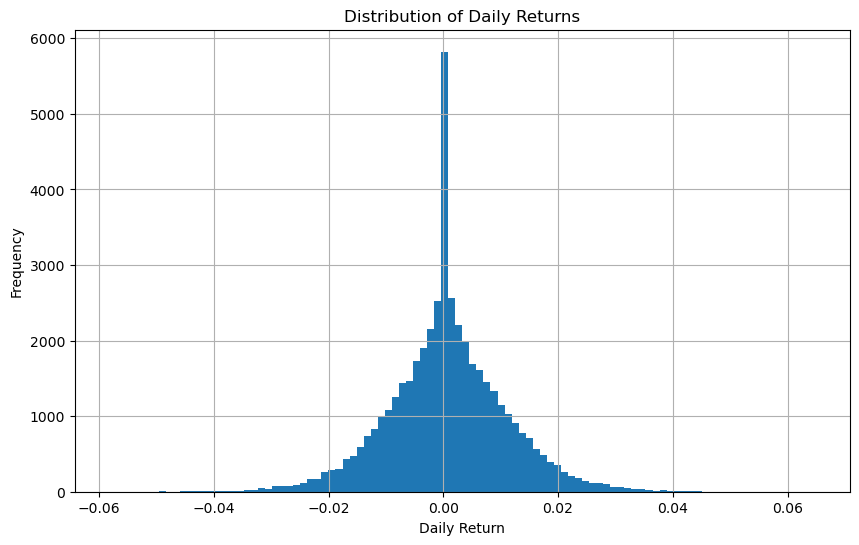

In [5]:
# Step 9 — Distribution Plot
plt.figure(figsize=(10,6))

plt.hist(
    returns["daily_return"],
    bins=100
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.grid(True)

plt.show() 

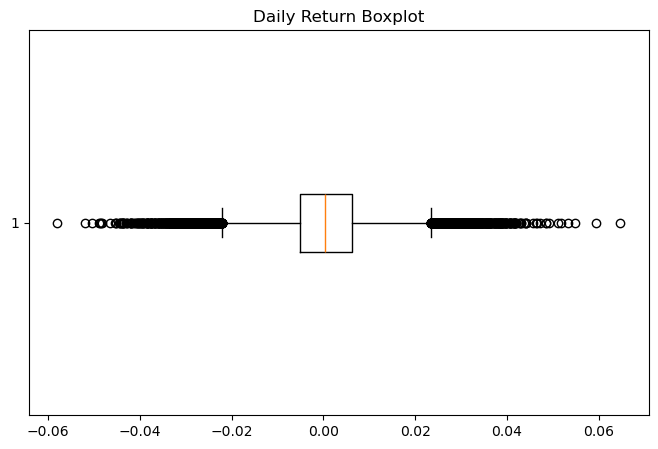

In [7]:
# Step 10 — Boxplot
plt.figure(figsize=(8,5))

plt.boxplot(
    returns["daily_return"],
    vert=False
)

plt.title("Daily Return Boxplot")

plt.show() 

In [8]:
returns.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\daily_returns.csv",
    index=False
) 

In [13]:
# 📘 Task 2: Compute CAGR (1-Year, 3-Year, 5-Year)
# Objective

# Compute: CAGR = (NAVend/NAVstart)^1/n - 1

# for:

# ✅ 1 Year
# ✅ 3 Years
# ✅ 5 Years

# for all 40 schemes, then build a comparison table. 

# Step 1: Prepare NAV Data
# Sort NAV history
nav = nav.sort_values(["amfi_code", "date"])

# Latest date available
latest_date = nav["date"].max()

print(latest_date)

# Step 2: Create CAGR Function
def calculate_cagr(df, years):
    
    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    period = df[df["date"] >= start_date]

    if len(period) < 2:
        return np.nan

    start_nav = period.iloc[0]["nav"]
    end_nav = period.iloc[-1]["nav"]

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    return cagr
    
# Step 3: Calculate CAGR for Every Fund
results = []

for code, df in nav.groupby("amfi_code"):

    results.append({

        "amfi_code": code,

        "CAGR_1Y": calculate_cagr(df, 1),

        "CAGR_3Y": calculate_cagr(df, 3),

        "CAGR_5Y": calculate_cagr(df, 5)

    })

# Step 4: Create DataFrame
cagr = pd.DataFrame(results)

# Step 5: Merge Scheme Names
cagr = cagr.merge(
    fund[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

# Step 6: Rearrange Columns
cagr = cagr[
[
    "amfi_code",
    "scheme_name",
    "CAGR_1Y",
    "CAGR_3Y",
    "CAGR_5Y"
]
]


# Step 7: Convert to Percentage
cagr["CAGR_1Y"] *= 100
cagr["CAGR_3Y"] *= 100
cagr["CAGR_5Y"] *= 100

# Step 8: Round Values
cagr = cagr.round(2)

# Step 9: Display
cagr.head() 

2026-05-29 00:00:00


,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.22,1.29,2.32
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.70,3.92,3.91
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,26.07
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,20.44
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.99,-4.15,6.95


In [14]:
# Step 10: Rank by 5-Year CAGR
cagr = cagr.sort_values(
    "CAGR_5Y",
    ascending=False
)

# Step 11: Save Report
cagr.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\cagr_report.csv",
    index=False
) 

In [15]:
# Quick Verification

# Run:

print(cagr.shape)

print(cagr.isnull().sum())

cagr.describe()  

(40, 5)
amfi_code      0
scheme_name    0
CAGR_1Y        0
CAGR_3Y        0
CAGR_5Y        0
dtype: int64


,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,19.428250,16.415250,14.541000
std,14534.998667,22.912863,12.206893,8.901683
min,100016.000000,-42.800000,-11.710000,1.030000
25%,118632.750000,7.382500,6.605000,6.012500
50%,119551.500000,17.475000,18.230000,14.475000
75%,120842.250000,27.165000,26.902500,21.255000
max,149324.000000,82.780000,35.110000,28.380000


In [16]:
# 📘 Task 3: Sharpe Ratio
# Objective

# Compute the annualized Sharpe Ratio for all 40 funds using:
# Sharpe Ratio=(Rp−Rf)/σp× sqrt(252) 

# Where:

# Rp = Average Daily Return
# Rf = Annual Risk-Free Rate = 6.5% (0.065)
# σ = Standard Deviation of Daily Returns
# 252 = Trading days per year 

# Step 1: Risk-Free Rate

# Convert the annual rate to a daily rate:

risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

# Step 2: Calculate Sharpe Ratio for Every Fund
sharpe_results = []

for code, df in returns.groupby("amfi_code"):

    mean_return = df["daily_return"].mean()

    std_return = df["daily_return"].std()

    if std_return == 0:
        sharpe = np.nan
    else:
        sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe
    })


# Step 3: Create DataFrame
sharpe = pd.DataFrame(sharpe_results)

# Step 4: Merge Scheme Names
sharpe = sharpe.merge(
    fund[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

# Step 5: Rearrange Columns
sharpe = sharpe[
[
    "amfi_code",
    "scheme_name",
    "Sharpe_Ratio"
]
]

# Step 6: Round Values
sharpe["Sharpe_Ratio"] = sharpe["Sharpe_Ratio"].round(4)

# Step 7: Rank All Funds
sharpe = sharpe.sort_values(
    by="Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

sharpe["Rank"] = sharpe.index + 1

# Step 8: Display Top 10
sharpe.head(10) 

,amfi_code,scheme_name,Sharpe_Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.4483,1
1,120843,Kotak Flexicap Fund - Regular - Growth,1.3067,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.2349,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,1.2083,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,1.1801,5
5,149323,DSP Midcap Fund - Regular - Growth,1.1321,6
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.0937,7
7,118632,Nippon India Large Cap Fund - Regular - Growth,1.0817,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,1.0272,9
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.0265,10


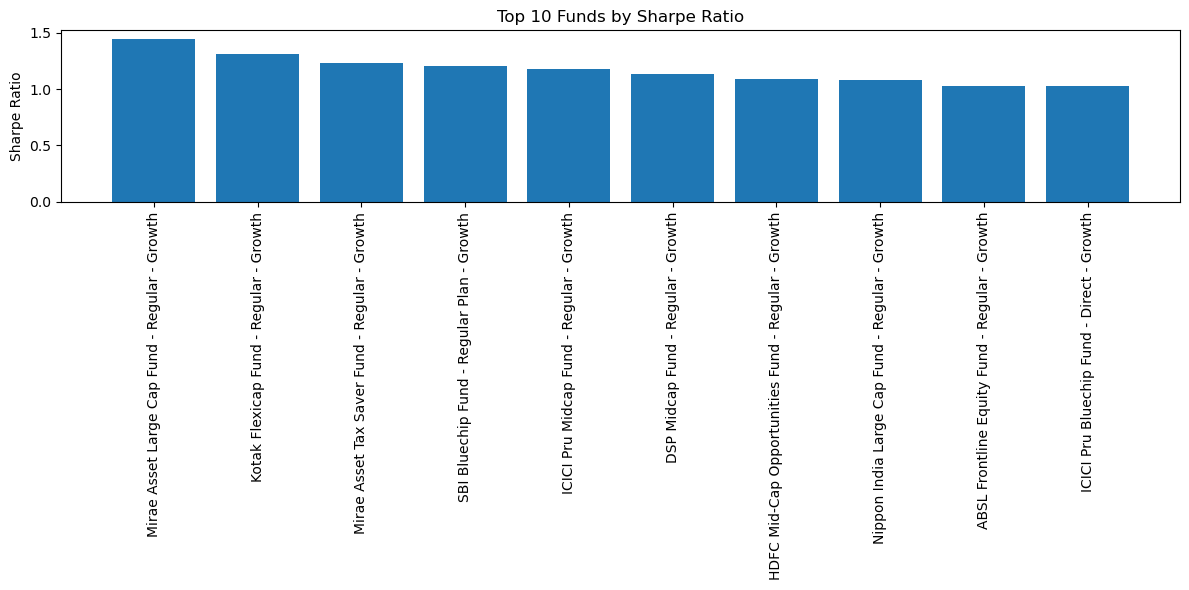

(40, 4)
0


,amfi_code,scheme_name,Sharpe_Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.4483,1
1,120843,Kotak Flexicap Fund - Regular - Growth,1.3067,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.2349,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,1.2083,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,1.1801,5


In [17]:
# Step 9: Plot Top 10
plt.figure(figsize=(12,6))

top10 = sharpe.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Sharpe_Ratio"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\sharpe_ratio_top10.png",
    dpi=300
)

plt.show()

# Step 10: Save Report
sharpe.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\sharpe_ratio_report.csv",
    index=False
)

# Quick Verification

# Run:

print(sharpe.shape)

print(sharpe["Sharpe_Ratio"].isnull().sum())

sharpe.head()

# Expected:

# 40 rows
# One row per scheme.
# Very few or no NaN values unless a fund has zero return volatility.
# Why this implementation?

# Using:

# daily_rf = 0.065 / 252

# ensures the risk-free rate is on the same daily scale as the daily returns before annualizing the Sharpe Ratio. This is the standard approach when working with daily return data.

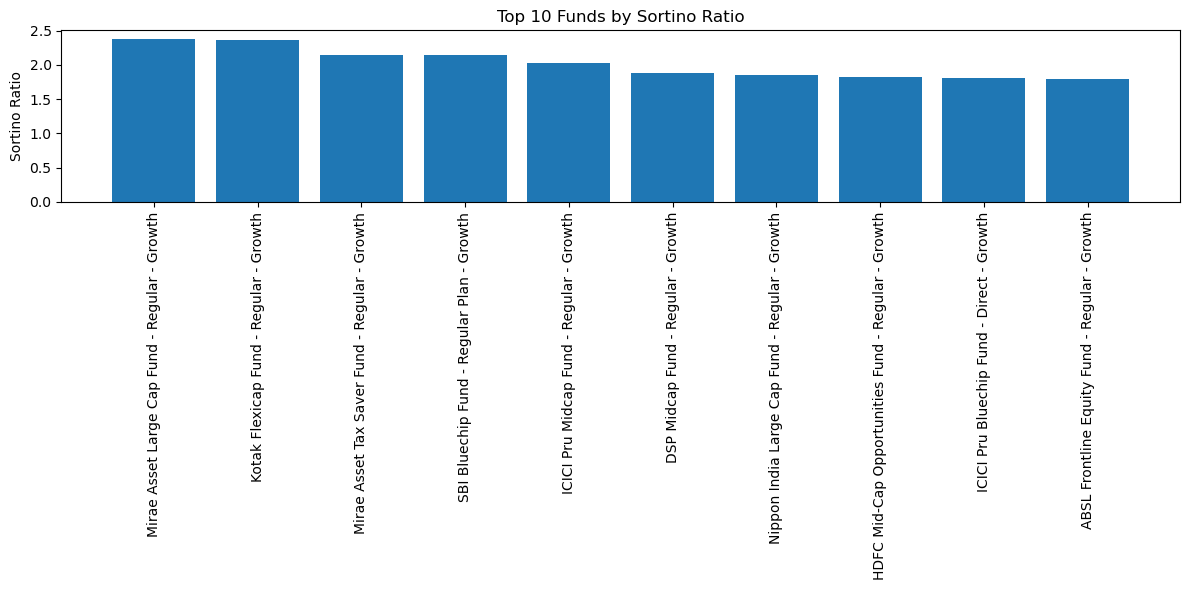

(40, 4)
0


,amfi_code,scheme_name,Sortino_Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.3856,1
1,120843,Kotak Flexicap Fund - Regular - Growth,2.3643,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.1469,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,2.1403,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,2.0294,5


In [19]:
# 📘 Task 4: Sortino Ratio
# Objective

# Compute the annualized Sortino Ratio for all 40 funds.

# Formula: same as task 3 
# The only difference from Sharpe is:

# Sharpe → uses all daily returns
# Sortino → uses only negative daily returns to calculate risk.
# Step 1: Risk-Free Rate

# (Reuse from Task 3)

risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

# Step 2: Calculate Sortino Ratio
sortino_results = []

for code, df in returns.groupby("amfi_code"):

    mean_return = df["daily_return"].mean()

    downside_returns = df.loc[
        df["daily_return"] < 0,
        "daily_return"
    ]

    downside_std = downside_returns.std()

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = (
            (mean_return - daily_rf)
            /
            downside_std
        ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": code,
        "Sortino_Ratio": sortino
    })


# Step 3: Create DataFrame
sortino = pd.DataFrame(sortino_results)

# Step 4: Merge Scheme Names
sortino = sortino.merge(
    fund[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

# Step 5: Arrange Columns
sortino = sortino[
[
    "amfi_code",
    "scheme_name",
    "Sortino_Ratio"
]
]

# Step 6: Round
sortino["Sortino_Ratio"] = (
    sortino["Sortino_Ratio"]
    .round(4)
)

# Step 7: Rank
sortino = sortino.sort_values(
    by="Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

sortino["Rank"] = (
    sortino.index + 1
)

# Step 8: Display Top 10
sortino.head(10)

# Step 9: Plot
plt.figure(figsize=(12,6))

top10 = sortino.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Sortino_Ratio"]
)

plt.xticks(rotation=90)

plt.ylabel("Sortino Ratio")

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\sortino_ratio_top10.png",
    dpi=300
)

plt.show()

# Step 10: Save Report
sortino.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\sortino_ratio_report.csv",
    index=False
)
# Verify

# Run:

print(sortino.shape)

print(sortino["Sortino_Ratio"].isnull().sum())

sortino.head()

# Expected:

# 40 rows
# One row per fund.
# Funds with very few or no negative-return days may have NaN values if the downside standard deviation cannot be computed.


In [23]:
 











# Step 5: Sort
nifty100 = nifty100.sort_values("date")

# Step 6: Benchmark Daily Returns
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

# Step 7: Keep Needed Columns
benchmark_returns = nifty100[
    ["date", "benchmark_return"]
].dropna()

# Step 8: Merge with Fund Returns

# We already have the returns DataFrame from Task 1.

merged = returns.merge(
    benchmark_returns,
    on="date",
    how="inner"
)

# Step 9: Regression
alpha_beta = []

for code, df in merged.groupby("amfi_code"):

    x = df["benchmark_return"]
    y = df["daily_return"]

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    alpha = intercept * 252

    beta = slope

    alpha_beta.append({

        "amfi_code": code,

        "Alpha": alpha,

        "Beta": beta

    })
    
# Step 10: Create DataFrame
alpha_beta = pd.DataFrame(alpha_beta)

# Step 11: Merge Scheme Names
alpha_beta = alpha_beta.merge(
    fund[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

# Step 12: Arrange Columns
alpha_beta = alpha_beta[
[
    "amfi_code",
    "scheme_name",
    "Alpha",
    "Beta"
]
]

# Step 13: Round
alpha_beta = alpha_beta.round(4)

# Step 14: Rank by Alpha
alpha_beta = alpha_beta.sort_values(
    by="Alpha",
    ascending=False
)

# Step 15: Display
alpha_beta.head(10)

# Expected:

# Scheme	Alpha	Beta
# ABC Fund	0.024	0.95
# XYZ Fund	0.021	1.08

# Step 16: Save Report
alpha_beta.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\alpha_beta.csv",
    index=False
)

# Step 17: Plot Beta
plt.figure(figsize=(12,6))

top10 = alpha_beta.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Beta"]
)

plt.xticks(rotation=90)

plt.title("Top Funds by Alpha (with Corresponding Beta)")

plt.ylabel("Beta")

plt.tight_layout()

plt.savefig(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\alpha_beta_chart.png",
    dpi=300
)

plt.show()

# Verify

# Run:

print(alpha_beta.shape)

alpha_beta.describe()

alpha_beta.head()

# Expected:

# 40 rows
# One row per fund.
# Alpha values may be positive or negative.
# Beta values are typically around 0.5–1.5, though some funds may lie outside this range depending on the dataset.

KeyError: 'amfi_code'

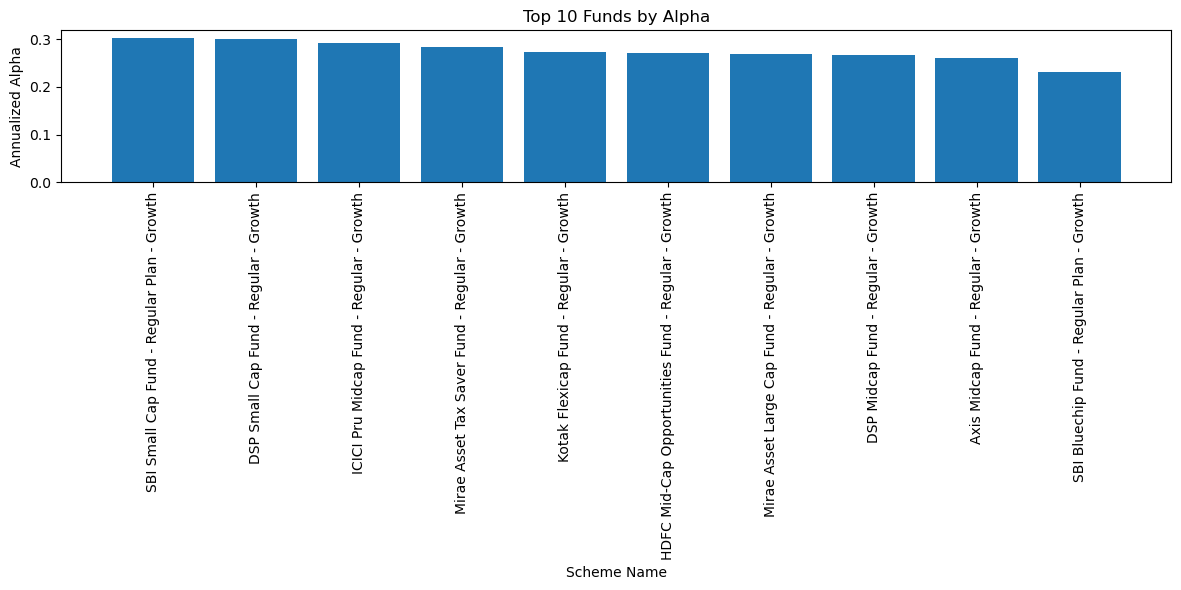

In [28]:
# 📘 Task 5: Alpha & Beta
# Objective

# Using OLS Regression:

# Independent Variable (X) → Nifty 100 Daily Returns
# Dependent Variable (Y) → Fund Daily Returns
# Compute:
# Beta = slope
# Alpha = intercept × 252 (annualized)
# using scipy.stats.linregress.
# Step 1: Import
from scipy.stats import linregress

# Step 2: Load Benchmark
benchmark = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\10_benchmark_indices.csv"
)

# Step 3: Convert Date
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# Step 4: Keep Only Nifty 100
# First check the exact benchmark names in your dataset.
# Run this:

benchmark["index_name"].unique() 

# Step 4
# Keep only NIFTY100 benchmark
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Step 5
# Sort benchmark data
nifty100 = nifty100.sort_values("date")

# Compute benchmark daily returns
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

# Step 6
# Keep only required columns
benchmark_returns = nifty100[
    ["date", "benchmark_return"]
].dropna()

# Step 7
# Merge benchmark returns with fund returns
merged = pd.merge(
    returns,
    benchmark_returns,
    on="date",
    how="inner"
)

# Step 8

from scipy.stats import linregress

alpha_beta_results = []

for code, df in merged.groupby("amfi_code"):

    # Skip funds with insufficient observations
    if len(df) < 2:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        df["benchmark_return"],
        df["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": code,
        "scheme_name": df["scheme_name"].iloc[0],
        "Alpha": intercept * 252,   # Annualized Alpha
        "Beta": slope
    })
    
# Step 9

alpha_beta = pd.DataFrame(alpha_beta_results)

# Step 10

alpha_beta["Alpha"] = alpha_beta["Alpha"].round(4)
alpha_beta["Beta"] = alpha_beta["Beta"].round(4)

# Step 11
alpha_beta = alpha_beta.sort_values(
    by="Alpha",
    ascending=False
).reset_index(drop=True)

alpha_beta["Rank"] = alpha_beta.index + 1

# Step 12
alpha_beta = alpha_beta[
    [
        "Rank",
        "amfi_code",
        "scheme_name",
        "Alpha",
        "Beta"
    ]
] 

# Step 13
alpha_beta.head(10)

# Step 14
alpha_beta.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\alpha_beta.csv",
    index=False
)

# Step 15 (Visualization)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top10 = alpha_beta.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Alpha"]
)

plt.xticks(rotation=90)

plt.xlabel("Scheme Name")
plt.ylabel("Annualized Alpha")
plt.title("Top 10 Funds by Alpha")

plt.tight_layout()

plt.savefig(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\alpha_beta_chart.png",
    dpi=300
)

plt.show() 


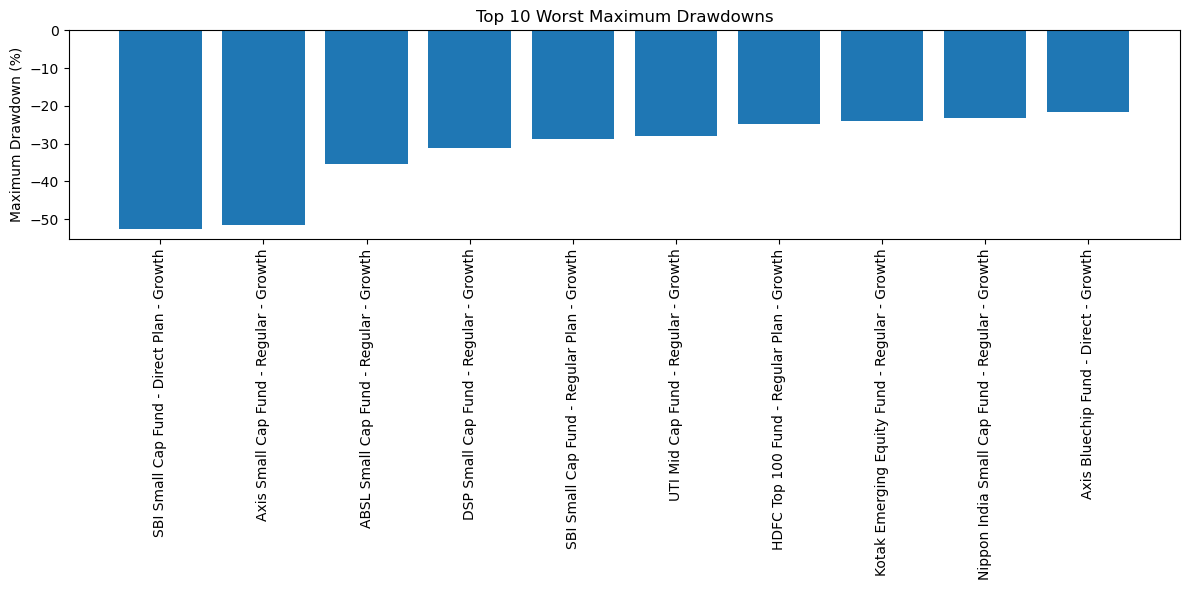

,Rank,amfi_code,scheme_name,Max_Drawdown,Peak_Date,Trough_Date
0,1,119599,SBI Small Cap Fund - Direct Plan - Growth,-52.57,2023-01-17,2025-10-28
1,2,119095,Axis Small Cap Fund - Regular - Growth,-51.68,2025-05-22,2026-05-11
2,3,101207,ABSL Small Cap Fund - Regular - Growth,-35.45,2024-11-21,2026-05-11
3,4,149324,DSP Small Cap Fund - Regular - Growth,-31.17,2026-04-24,2025-01-03
4,5,119598,SBI Small Cap Fund - Regular Plan - Growth,-28.71,2026-05-22,2025-05-14


In [30]:
# 📘 Task 6: Maximum Drawdown
# Objective

# Compute: Drawdown=(NAV / Running Maximum NAV)−1
# Then, for each fund:

# Maximum Drawdown (most negative value)
# Start Date of drawdown
# End Date of drawdown

# Finally, create maximum_drawdown.csv. 

# Step 1: Sort NAV Data
nav = nav.sort_values(
    ["amfi_code", "date"]
)

# Step 2: Calculate Running Maximum NAV
nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
       .cummax()
)

# Step 3: Calculate Drawdown
nav["drawdown"] = (
    nav["nav"] /
    nav["running_max"]
) - 1

# Step 4: Compute Maximum Drawdown for Each Fund
mdd_results = []

for code, df in nav.groupby("amfi_code"):

    # Row having worst drawdown
    worst = df.loc[df["drawdown"].idxmin()]

    # Peak NAV before the drawdown
    peak_date = df.loc[
        df["nav"][:worst.name].idxmax(),
        "date"
    ]

    mdd_results.append({

        "amfi_code": code,

        "scheme_name": fund.loc[
            fund["amfi_code"] == code,
            "scheme_name"
        ].iloc[0],

        "Max_Drawdown": worst["drawdown"],

        "Peak_Date": peak_date,

        "Trough_Date": worst["date"]

    })


# Step 5: Create DataFrame
maximum_drawdown = pd.DataFrame(mdd_results)

# Step 6: Convert Percentage
maximum_drawdown["Max_Drawdown"] = (
    maximum_drawdown["Max_Drawdown"] * 100
)

# Step 7: Round
maximum_drawdown["Max_Drawdown"] = (
    maximum_drawdown["Max_Drawdown"]
    .round(2)
)

# Step 8: Rank
maximum_drawdown = maximum_drawdown.sort_values(
    by="Max_Drawdown"
).reset_index(drop=True)

maximum_drawdown["Rank"] = (
    maximum_drawdown.index + 1
)

# Step 9: Arrange Columns
maximum_drawdown = maximum_drawdown[
[
    "Rank",
    "amfi_code",
    "scheme_name",
    "Max_Drawdown",
    "Peak_Date",
    "Trough_Date"
]
]

# Step 10: Display
maximum_drawdown.head(10)

# Step 11: Save CSV
maximum_drawdown.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\maximum_drawdown.csv",
    index=False
)

# Step 12: Plot Top 10 Worst Drawdowns
plt.figure(figsize=(12,6))

top10 = maximum_drawdown.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Max_Drawdown"]
)

plt.xticks(rotation=90)

plt.ylabel("Maximum Drawdown (%)")

plt.title("Top 10 Worst Maximum Drawdowns")

plt.tight_layout()

plt.savefig(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\maximum_drawdown_chart.png",
    dpi=300
)

plt.show()

# Verify
maximum_drawdown.shape
maximum_drawdown.head()



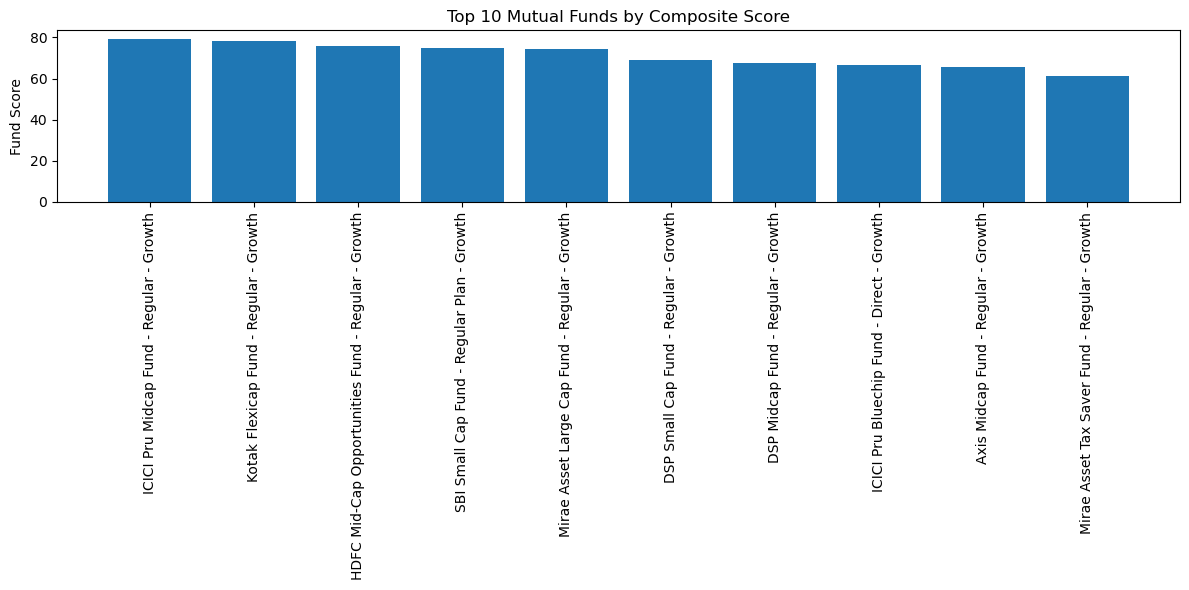

In [33]:
# 📘 Task 7: Fund Scorecard (0–100)
# Formula (Given in your assignment)
# Score=30%×3-Year Return Rank+25%×Sharpe Rank+20%×Alpha Rank+15%×Expense Ratio Rank (Inverse)+10%×Maximum Drawdown Rank (Inverse)
# Step 1: Load Required Files
import pandas as pd

performance = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\07_scheme_performance.csv"
) 
sharpe = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\sharpe_ratio_report.csv"
)

alpha_beta = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\alpha_beta.csv"
)

drawdown = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\maximum_drawdown.csv"
)

# Step 2: Merge All Metrics
scorecard = performance.merge(
    sharpe[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown[["amfi_code", "Max_Drawdown"]],
    on="amfi_code"
)

# Step 3: Create Ranks

# Higher return = better

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)

# Higher Sharpe = better

scorecard["sharpe_rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False
)

# Higher Alpha = better

scorecard["alpha_rank"] = scorecard["Alpha"].rank(
    ascending=False
)

# Lower Expense Ratio = better

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

# Lower Drawdown = better

scorecard["drawdown_rank"] = scorecard["Max_Drawdown"].abs().rank(
    ascending=True
)

# Step 4: Convert Ranks into Scores (0–100)
n = len(scorecard)

scorecard["return_score"] = (
    (n - scorecard["return_rank"]) / (n - 1)
) * 100

scorecard["sharpe_score"] = (
    (n - scorecard["sharpe_rank"]) / (n - 1)
) * 100

scorecard["alpha_score"] = (
    (n - scorecard["alpha_rank"]) / (n - 1)
) * 100

scorecard["expense_score"] = (
    (n - scorecard["expense_rank"]) / (n - 1)
) * 100

scorecard["drawdown_score"] = (
    (n - scorecard["drawdown_rank"]) / (n - 1)
) * 100

# Step 5: Final Composite Score
scorecard["Fund_Score"] = (

      scorecard["return_score"] * 0.30

    + scorecard["sharpe_score"] * 0.25

    + scorecard["alpha_score"] * 0.20

    + scorecard["expense_score"] * 0.15

    + scorecard["drawdown_score"] * 0.10

)

# Step 6: Round
scorecard["Fund_Score"] = scorecard["Fund_Score"].round(2)

# Step 7: Rank Funds
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
).reset_index(drop=True)

scorecard["Overall_Rank"] = scorecard.index + 1

# Step 8: Final Table
fund_scorecard = scorecard[
    [
        "Overall_Rank",
        "amfi_code",
        "scheme_name",
        "fund_house",
        "Fund_Score",
        "return_3yr_pct",
        "Sharpe_Ratio",
        "Alpha",
        "expense_ratio_pct",
        "Max_Drawdown"
    ]
] 

# Step 9: Display
fund_scorecard.head(10)

# Step 10: Save CSV
fund_scorecard.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\fund_scorecard.csv",
    index=False
)

# Step 11: Plot Top 10 Funds
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top10 = fund_scorecard.head(10)

plt.bar(
    top10["scheme_name"],
    top10["Fund_Score"]
)

plt.xticks(rotation=90)

plt.ylabel("Fund Score")

plt.title("Top 10 Mutual Funds by Composite Score")

plt.tight_layout()

plt.savefig(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\fund_scorecard_chart.png",
    dpi=300
)

plt.show()   

['ICICI Pru Midcap Fund - Regular - Growth', 'Kotak Flexicap Fund - Regular - Growth', 'HDFC Mid-Cap Opportunities Fund - Regular - Growth', 'SBI Small Cap Fund - Regular Plan - Growth', 'Mirae Asset Large Cap Fund - Regular - Growth']


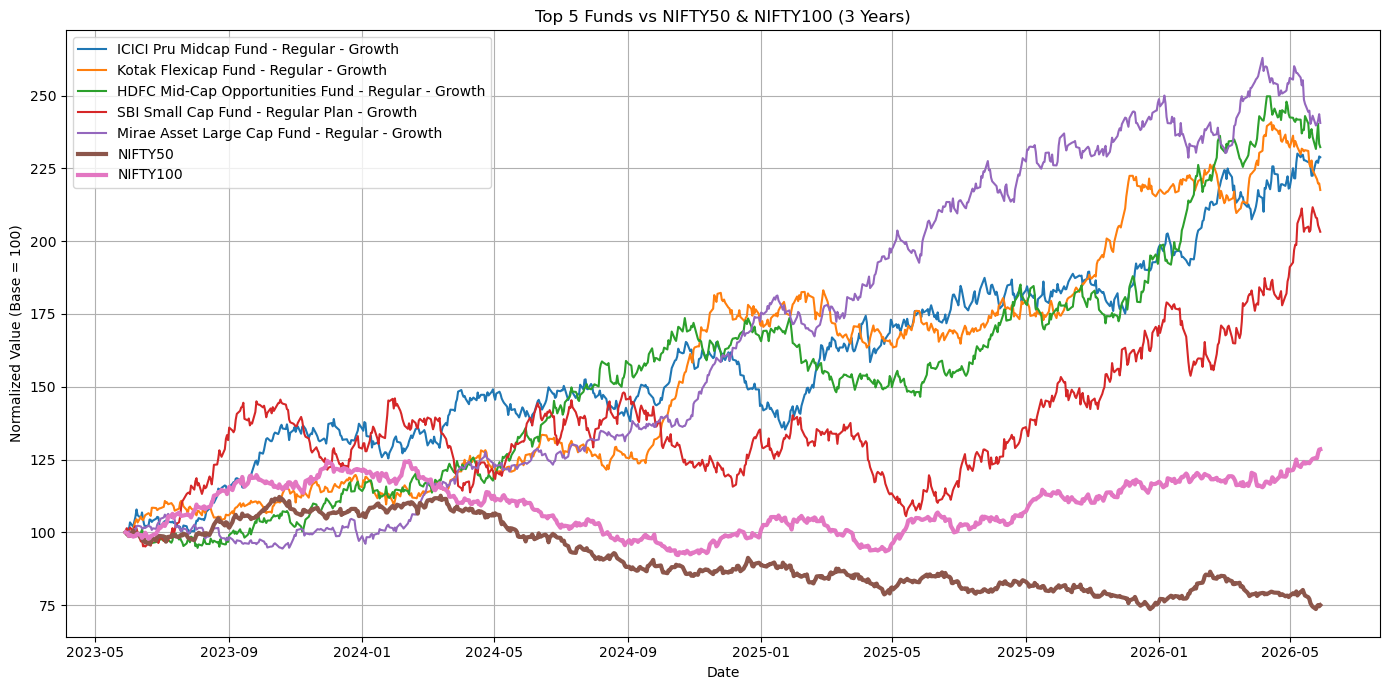

In [34]:
# 📘 Task 8: Benchmark Comparison & Tracking Error
# Deliverables
# ✅ benchmark_comparison.png
# ✅ tracking_error.csv
# Step 1: Load Data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# NAV history
nav = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\02_nav_history.csv"
)

# Benchmark data
benchmark = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\10_benchmark_indices.csv"
)

# Fund Scorecard
scorecard = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\fund_scorecard.csv"
)

# Fund master
fund = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\01_fund_master.csv"
)

# Step 2: Convert Dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Step 3: Select Top 5 Funds
top5 = scorecard.head(5)

top5_codes = top5["amfi_code"].tolist()

top5_names = top5["scheme_name"].tolist()

print(top5_names)

# Step 4: Keep Last 3 Years
latest = nav["date"].max()

start = latest - pd.DateOffset(years=3)

nav3 = nav[nav["date"] >= start]

benchmark3 = benchmark[
    benchmark["date"] >= start
]

# Step 5: Keep NIFTY50 & NIFTY100
benchmark3 = benchmark3[
    benchmark3["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
]

# Step 6: Normalize NAV

# This makes every line start at 100.

plt.figure(figsize=(14,7))

for code in top5_codes:

    df = nav3[
        nav3["amfi_code"] == code
    ].copy()

    df = df.sort_values("date")

    df["normalized"] = (
        df["nav"] /
        df["nav"].iloc[0]
    ) * 100

    name = fund.loc[
        fund["amfi_code"] == code,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        df["date"],
        df["normalized"],
        label=name
    )

# Step 7: Add Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:

    df = benchmark3[
        benchmark3["index_name"] == idx
    ].copy()

    df = df.sort_values("date")

    df["normalized"] = (
        df["close_value"] /
        df["close_value"].iloc[0]
    ) * 100

    plt.plot(
        df["date"],
        df["normalized"],
        linewidth=3,
        label=idx
    )


# Step 8: Format Plot
plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

# Step 9: Save Figure
plt.savefig(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\benchmark_comparison.png",
    dpi=300
)

plt.show()


# Step 10: Tracking Error
benchmark100 = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

benchmark100 = benchmark100.sort_values("date")

benchmark100["benchmark_return"] = (
    benchmark100["close_value"].pct_change()
)

benchmark100 = benchmark100[
    ["date","benchmark_return"]
].dropna()

# Step 11: Calculate Tracking Error
tracking_results = []

for code in top5_codes:

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    df = df.sort_values("date")

    df["fund_return"] = df["nav"].pct_change()

    merged = df.merge(
        benchmark100,
        on="date",
        how="inner"
    )

    tracking_error = (
        (merged["fund_return"] -
         merged["benchmark_return"]).std()
    ) * np.sqrt(252)

    tracking_results.append({

        "amfi_code": code,

        "scheme_name":
        fund.loc[
            fund["amfi_code"]==code,
            "scheme_name"
        ].iloc[0],

        "Tracking_Error":
        round(tracking_error,4)

    })


# Step 12: Create Report
tracking_error = pd.DataFrame(
    tracking_results
)

tracking_error

# Step 13: Save CSV
tracking_error.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\tracking_error.csv",
    index=False
)